# Неделя 5 — адаптивная калибровка RUL-прогноза

## 1. Идея недели

На Week 4 лучший результат был получен через robust evolutionary search и conservative shift. Однако constant shift имеет ограничение: он отнимает одно и то же число циклов у всех двигателей. Это грубая поправка, потому что неопределённость модели может быть разной для разных test units.

На Week 5 мы проверяем более адаптивный подход:
- вместо среднего прогноза RandomForest берём нижние квантили предсказаний отдельных деревьев;
- отдельно проверяем residual correction model, которая пытается исправлять ошибку базовой модели.

Основная идея:
constant shift = одинаковая поправка для всех;
quantile prediction = осторожная поправка с учётом разброса предсказаний деревьев;
residual correction = отдельная модель, которая учится предсказывать ошибку базовой модели.

## 2. Imports and configuration

In [44]:
import hashlib
import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
USE_WEEK4_BEST_CANDIDATE = True

random_state = RANDOM_STATE
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_DIR = Path("CMAPSSData")

quantile_grid = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
shift_grid = np.arange(0, 5.5, 0.5)
residual_shift_grid = np.arange(0, 5.5, 0.5)

final_rf_base = {"n_estimators": 400, "random_state": RANDOM_STATE, "n_jobs": -1}

columns = [
    "unit_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21",
]

target_col = "Remaining Useful Life"
eps = 1e-6
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

In [45]:
def none_if_missing(value):
    if value is None:
        return None
    if isinstance(value, str) and value in {"None", "nan", "NaN", ""}:
        return None
    try:
        if pd.isna(value):
            return None
    except TypeError:
        pass
    return value


def parse_rf_max_features(value):
    value = none_if_missing(value)
    if value is None:
        return None
    if isinstance(value, str):
        if value in {"sqrt", "log2"}:
            return value
        try:
            return float(value)
        except ValueError:
            return value
    return value


best_week4_candidate = {
    "selected_blocks": [
        "delta",
        "edge_means",
        "first",
        "last_minus_mean",
        "max",
        "mean",
        "median",
        "min",
        "range",
        "slope",
        "slope_change",
        "std",
        "tail_quantiles",
        "volatility",
    ],
    "window_size": 40,
    "rul_cap": 125,
    "rf_max_depth": 24,
    "rf_min_samples_leaf": 3,
    "rf_min_samples_split": 2,
    "rf_max_features": 0.4,
}
old_week4_shift = 2.0
best_week4_hash = "a0f534b1f9e95faf884488db1b38a229"
week4_candidate_source = "явно зафиксировано по лучшему Week 4 candidate"

pd.DataFrame(
    [
        {
            **best_week4_candidate,
            "old_week4_shift": old_week4_shift,
            "candidate_hash": best_week4_hash,
            "source": week4_candidate_source,
        }
    ]
)

,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,old_week4_shift,candidate_hash,source
0,"[delta, edge_means, first, last_minus_mean, ma...",40,125,24,3,2,0.4,2.0,a0f534b1f9e95faf884488db1b38a229,явно зафиксировано по лучшему Week 4 candidate


## 3. Data loading

Используем FD001: train, test и official RUL. Для train целевая переменная считается как разница между последним циклом двигателя и текущим циклом. Для official test используем последнее доступное окно каждого test unit и истинный RUL из `RUL_FD001.txt`.

In [46]:
def load_cmapss_fd001(data_dir):
    train_df = pd.read_table(
        data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    test_df = pd.read_table(
        data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    rul_test_df = pd.read_table(
        data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
    )
    return train_df, test_df, rul_test_df


def add_rul_target(train_df):
    train_df = train_df.copy()
    max_cycle = train_df.groupby("unit_id")["cycle"].max()
    train_df[target_col] = train_df["unit_id"].map(max_cycle) - train_df["cycle"]
    return train_df


train_df, test_df, rul_test_df = load_cmapss_fd001(DATA_DIR)
train_df = add_rul_target(train_df)
y_test_official = rul_test_df["RUL"].reset_index(drop=True)
feature_source_cols = [
    col
    for col in train_df.columns
    if col.startswith("op_setting_") or col.startswith("sensor_")
]

pd.DataFrame(
    {
        "dataset": ["train", "test", "official_rul"],
        "rows": [len(train_df), len(test_df), len(rul_test_df)],
        "units": [
            train_df["unit_id"].nunique(),
            test_df["unit_id"].nunique(),
            len(rul_test_df),
        ],
    }
)

,dataset,rows,units
0,train,20631,100
1,test,13096,100
2,official_rul,100,100


## 4. Воспроизведение лучшей Week 4 модели

Воспроизводим лучший Week 4 candidate: aggregated features, capped RUL target, RandomForest mean prediction и calibrated shift.

In [47]:
all_feature_blocks = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "delta",
    "slope",
    "last_minus_mean",
    "median",
    "iqr",
    "first",
    "last",
    "relative_delta",
    "relative_last_minus_mean",
    "rms",
    "edge_means",
    "slope_change",
    "tail_quantiles",
    "robust_spread",
    "volatility",
]


def calculate_slope(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    x = np.arange(len(values), dtype=float)
    x = x - x.mean()
    denominator = np.sum(x**2)
    if denominator == 0:
        return 0.0
    return float(np.dot(values, x) / denominator)


def calculate_rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values**2))) if len(values) else 0.0


def calculate_slope_change(values):
    values = np.asarray(values, dtype=float)
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0.0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def calculate_volatility(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    return float(np.mean(np.abs(np.diff(values))))


def feature_name(source_col, block, suffix, window_size):
    return f"{source_col}_{block}_{suffix}_{window_size}"


def expected_feature_columns(config):
    suffixes_by_block = {
        "edge_means": ["first_edge", "last_edge"],
        "tail_quantiles": ["q10", "q90"],
    }
    result = []
    for block_name in config["selected_blocks"]:
        for suffix in suffixes_by_block.get(block_name, ["value"]):
            for source_col in feature_source_cols:
                result.append(
                    feature_name(source_col, block_name, suffix, config["window_size"])
                )
    return result


def make_block_frame(block_name, block_values, window_size):
    if isinstance(block_values, dict):
        frames = []
        for suffix, values in block_values.items():
            frame = values.copy()
            frame.columns = [
                feature_name(col, block_name, suffix, window_size)
                for col in frame.columns
            ]
            frames.append(frame)
        return pd.concat(frames, axis=1)
    frame = block_values.copy()
    frame.columns = [
        feature_name(col, block_name, "value", window_size) for col in frame.columns
    ]
    return frame


def build_rolling_feature_blocks(sorted_df, config, require_full_window):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    min_periods = window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1
    rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(
        window=window_size, min_periods=min_periods
    )
    edge_rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(
        window=edge_window_size, min_periods=edge_min_periods
    )
    mean_features = rolling.mean().reset_index(level=0, drop=True)
    std_features = rolling.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_features = rolling.min().reset_index(level=0, drop=True)
    max_features = rolling.max().reset_index(level=0, drop=True)
    median_features = rolling.median().reset_index(level=0, drop=True)
    q10_features = rolling.quantile(0.10).reset_index(level=0, drop=True)
    q25_features = rolling.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling.quantile(0.75).reset_index(level=0, drop=True)
    q90_features = rolling.quantile(0.90).reset_index(level=0, drop=True)
    first_features = sorted_df.groupby("unit_id")[feature_source_cols].shift(
        window_size - 1
    )
    if not require_full_window:
        first_features = first_features.fillna(
            sorted_df.groupby("unit_id")[feature_source_cols].transform("first")
        )
    last_features = sorted_df[feature_source_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    block_values = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": max_features - min_features,
        "delta": delta_features,
        "slope": rolling.apply(calculate_slope, raw=True).reset_index(
            level=0, drop=True
        ),
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": q75_features - q25_features,
        "first": first_features,
        "last": last_features,
        "relative_delta": delta_features / (first_features.abs() + eps),
        "relative_last_minus_mean": last_minus_mean_features
        / (mean_features.abs() + eps),
        "rms": rolling.apply(calculate_rms, raw=True).reset_index(level=0, drop=True),
        "edge_means": {
            "first_edge": rolling.apply(
                lambda values: np.mean(values[:edge_window_size]), raw=True
            ).reset_index(level=0, drop=True),
            "last_edge": edge_rolling.mean().reset_index(level=0, drop=True),
        },
        "slope_change": rolling.apply(calculate_slope_change, raw=True).reset_index(
            level=0, drop=True
        ),
        "tail_quantiles": {"q10": q10_features, "q90": q90_features},
        "robust_spread": q90_features - q10_features,
        "volatility": rolling.apply(calculate_volatility, raw=True).reset_index(
            level=0, drop=True
        ),
    }
    return pd.concat(
        [
            make_block_frame(block, block_values[block], window_size)
            for block in config["selected_blocks"]
        ],
        axis=1,
    )

In [48]:
def single_history_feature_row(history_df, config):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    window_df = history_df.sort_values("cycle").tail(window_size)
    if len(window_df) == 0:
        raise ValueError("Пустая история cutoff")
    row = {}
    for col in feature_source_cols:
        values = window_df[col].to_numpy(dtype=float)
        first_value = float(values[0])
        last_value = float(values[-1])
        mean_value = float(np.mean(values))
        min_value = float(np.min(values))
        max_value = float(np.max(values))
        q10_value = float(np.quantile(values, 0.10))
        q25_value = float(np.quantile(values, 0.25))
        q75_value = float(np.quantile(values, 0.75))
        q90_value = float(np.quantile(values, 0.90))
        values_by_block = {
            "mean": [("value", mean_value)],
            "std": [("value", float(np.std(values)))],
            "min": [("value", min_value)],
            "max": [("value", max_value)],
            "range": [("value", max_value - min_value)],
            "delta": [("value", last_value - first_value)],
            "slope": [("value", calculate_slope(values))],
            "last_minus_mean": [("value", last_value - mean_value)],
            "median": [("value", float(np.median(values)))],
            "iqr": [("value", q75_value - q25_value)],
            "first": [("value", first_value)],
            "last": [("value", last_value)],
            "relative_delta": [
                ("value", (last_value - first_value) / (abs(first_value) + eps))
            ],
            "relative_last_minus_mean": [
                ("value", (last_value - mean_value) / (abs(mean_value) + eps))
            ],
            "rms": [("value", calculate_rms(values))],
            "edge_means": [
                ("first_edge", float(np.mean(values[:edge_window_size]))),
                ("last_edge", float(np.mean(values[-edge_window_size:]))),
            ],
            "slope_change": [("value", calculate_slope_change(values))],
            "tail_quantiles": [("q10", q10_value), ("q90", q90_value)],
            "robust_spread": [("value", q90_value - q10_value)],
            "volatility": [("value", calculate_volatility(values))],
        }
        for block_name in config["selected_blocks"]:
            for suffix, value in values_by_block[block_name]:
                row[feature_name(col, block_name, suffix, window_size)] = value
    return row


def build_aggregated_features_for_units(
    df, config, mode, validation_cutoffs=None, cap_target=True
):
    expected_columns = expected_feature_columns(config)
    if mode == "train":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(
            sorted_df, config, require_full_window=True
        )
        result_df = pd.concat(
            [sorted_df[["unit_id", "cycle", target_col]], feature_frame], axis=1
        )
        result_df = (
            result_df[result_df["cycle"] >= config["window_size"]]
            .dropna()
            .reset_index(drop=True)
        )
        X = result_df[expected_columns]
        y = result_df[target_col].reset_index(drop=True)
        if cap_target and config["rul_cap"] is not None:
            y = y.clip(upper=config["rul_cap"])
        return X, y
    if mode == "official_test":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(
            sorted_df, config, require_full_window=False
        )
        result_df = (
            pd.concat([sorted_df[["unit_id", "cycle"]], feature_frame], axis=1)
            .dropna()
            .reset_index(drop=True)
        )
        last_rows = (
            result_df.sort_values(["unit_id", "cycle"])
            .groupby("unit_id")
            .tail(1)
            .sort_values("unit_id")
            .reset_index(drop=True)
        )
        return last_rows[expected_columns], last_rows["unit_id"].reset_index(drop=True)
    if mode == "validation_cutoff":
        grouped = {
            unit_id: unit_df.sort_values("cycle")
            for unit_id, unit_df in df.groupby("unit_id")
        }
        rows = []
        y_values = []
        ids = []
        for validation_row in validation_cutoffs.itertuples(index=False):
            history_df = grouped[validation_row.unit_id]
            history_df = history_df[history_df["cycle"] <= validation_row.cutoff_cycle]
            rows.append(single_history_feature_row(history_df, config))
            y_values.append(validation_row.true_rul)
            ids.append(f"{validation_row.unit_id}_{validation_row.cutoff_cycle}")
        X = pd.DataFrame(rows).reindex(columns=expected_columns)
        if X.isna().any().any():
            raise ValueError("Validation-признаки содержат NaN")
        return X, pd.Series(y_values), pd.Series(ids)
    raise ValueError(f"Unknown mode: {mode}")

In [49]:
def build_rf_params(candidate, base):
    params = base.copy()
    params.update(
        {
            "max_depth": candidate["rf_max_depth"],
            "min_samples_leaf": candidate["rf_min_samples_leaf"],
            "min_samples_split": candidate["rf_min_samples_split"],
            "max_features": candidate["rf_max_features"],
        }
    )
    return params


def build_error_table(y_true, y_pred, model_name, ids=None):
    ids = np.arange(len(y_true)) if ids is None else ids
    error_df = pd.DataFrame(
        {
            "model_name": model_name,
            "id": ids,
            "true_rul": np.asarray(y_true),
            "pred_rul": np.asarray(y_pred),
        }
    )
    error_df["error"] = error_df["pred_rul"] - error_df["true_rul"]
    error_df["abs_error"] = error_df["error"].abs()
    return error_df


def zone_subset(error_df, zone):
    if zone == "near_failure":
        return error_df[error_df["true_rul"] <= 30]
    if zone == "warning_zone":
        return error_df[(error_df["true_rul"] > 30) & (error_df["true_rul"] <= 70)]
    return error_df


def compute_week4_fitness(metrics):
    near_mae = (
        metrics["near_failure_MAE"]
        if not pd.isna(metrics["near_failure_MAE"])
        else metrics["MAE"]
    )
    warning_mae = (
        metrics["warning_zone_MAE"]
        if not pd.isna(metrics["warning_zone_MAE"])
        else metrics["MAE"]
    )
    return (
        metrics["MAE"]
        + 4.0 * metrics["overestimation_share"]
        + 0.08 * near_mae
        + 0.04 * warning_mae
        + 0.03 * metrics["max_overestimation"]
    )


def metrics_from_error(error_df):
    over = error_df.loc[error_df["error"] > 0, "error"]
    near = zone_subset(error_df, "near_failure")
    warning = zone_subset(error_df, "warning_zone")
    metrics = {
        "MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error": float(error_df["error"].mean()),
        "overestimation_share": float((error_df["error"] > 0).mean()),
        "max_overestimation": float(over.max()) if len(over) else 0.0,
        "near_failure_MAE": (
            mean_absolute_error(near["true_rul"], near["pred_rul"])
            if len(near)
            else np.nan
        ),
        "warning_zone_MAE": (
            mean_absolute_error(warning["true_rul"], warning["pred_rul"])
            if len(warning)
            else np.nan
        ),
    }
    metrics["fitness"] = compute_week4_fitness(metrics)
    return metrics


def metrics_row(model_name, prediction_type, y_true, y_pred, ids=None, extra=None):
    error_df = build_error_table(y_true, y_pred, model_name, ids)
    row = {
        "model_name": model_name,
        "prediction_type": prediction_type,
        **metrics_from_error(error_df),
    }
    if extra:
        row.update(extra)
    return row, error_df


def safety_summary(error_df):
    return pd.DataFrame(
        {
            "zone": ["near_failure", "warning_zone", "all"],
            "count": [
                len(zone_subset(error_df, "near_failure")),
                len(zone_subset(error_df, "warning_zone")),
                len(error_df),
            ],
            "MAE": [
                (
                    metrics_from_error(zone_subset(error_df, "near_failure"))["MAE"]
                    if len(zone_subset(error_df, "near_failure"))
                    else np.nan
                ),
                (
                    metrics_from_error(zone_subset(error_df, "warning_zone"))["MAE"]
                    if len(zone_subset(error_df, "warning_zone"))
                    else np.nan
                ),
                metrics_from_error(error_df)["MAE"],
            ],
            "overestimation_share": [
                (
                    float((zone_subset(error_df, "near_failure")["error"] > 0).mean())
                    if len(zone_subset(error_df, "near_failure"))
                    else np.nan
                ),
                (
                    float((zone_subset(error_df, "warning_zone")["error"] > 0).mean())
                    if len(zone_subset(error_df, "warning_zone"))
                    else np.nan
                ),
                float((error_df["error"] > 0).mean()),
            ],
        }
    )


def rul_zone_analysis(error_df):
    bins = [-1, 30, 70, 125, np.inf]
    labels = ["0-30", "31-70", "71-125", "126+"]
    zoned = error_df.copy()
    zoned["rul_zone"] = pd.cut(zoned["true_rul"], bins=bins, labels=labels)
    rows = []
    for zone, group in zoned.groupby("rul_zone", observed=False):
        if len(group):
            rows.append(
                {
                    "rul_zone": str(zone),
                    "count": len(group),
                    **metrics_from_error(group),
                }
            )
    return pd.DataFrame(rows)

In [50]:
start = time.perf_counter()
X_train_week4, y_train_week4 = build_aggregated_features_for_units(
    train_df, best_week4_candidate, "train"
)
X_test_week4, official_unit_ids = build_aggregated_features_for_units(
    test_df, best_week4_candidate, "official_test"
)
rf_model = RandomForestRegressor(**build_rf_params(best_week4_candidate, final_rf_base))
rf_model.fit(X_train_week4, y_train_week4)
pred_mean = rf_model.predict(X_test_week4)
pred_mean_shifted = np.maximum(pred_mean - old_week4_shift, 0)
train_seconds = time.perf_counter() - start

baseline_shift_row, baseline_shift_error_df = metrics_row(
    "Week 4 calibrated baseline",
    "mean_shifted",
    y_test_official,
    pred_mean_shifted,
    official_unit_ids,
)
baseline_metrics_df = pd.DataFrame([baseline_shift_row])
baseline_week4 = baseline_metrics_df.iloc[0]

pd.DataFrame(
    {
        "train_rows": [len(X_train_week4)],
        "test_units": [len(X_test_week4)],
        "features": [X_train_week4.shape[1]],
        "train_seconds": [train_seconds],
    }
)

,train_rows,test_units,features,train_seconds
0,16731,100,384,41.696762


In [51]:
baseline_metrics_df[
    [
        "model_name",
        "prediction_type",
        "fitness",
        "MAE",
        "RMSE",
        "R2",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

,model_name,prediction_type,fitness,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,Week 4 calibrated baseline,mean_shifted,12.946757,9.449429,13.159902,0.899713,-1.378648,0.48,35.059084,2.579192,7.980507


In [52]:
safety_summary(baseline_shift_error_df)

,zone,count,MAE,overestimation_share
0,near_failure,25,2.579192,0.480000
1,warning_zone,17,7.980507,0.705882
2,all,100,9.449429,0.480000


In [53]:
rul_zone_analysis(baseline_shift_error_df)

,rul_zone,count,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,fitness
0,0-30,25,2.579192,3.400207,0.782850,0.175700,0.480000,6.106610,2.579192,NaN,4.991894
1,31-70,17,7.980507,10.319268,-0.152961,3.704322,0.705882,29.002593,NaN,7.980507,12.631775
2,71-125,47,10.666494,14.150103,-0.093768,0.813583,0.510638,35.059084,NaN,NaN,15.040799
3,126+,11,22.133563,22.979019,-15.307369,-22.133563,0.000000,0.000000,NaN,NaN,24.789591


## 5. Quantile RandomForest prediction

RandomForest состоит из многих деревьев. Обычно sklearn возвращает среднее предсказание деревьев:

`pred_mean = mean(tree_predictions)`

Но можно взять нижний квантиль:

`pred_q = quantile(tree_predictions, q)`

Нижний квантиль делает прогноз более осторожным не одинаковым fixed shift, а через разброс отдельных деревьев для каждого test unit.

In [54]:
tree_predictions = np.array(
    [tree.predict(X_test_week4) for tree in rf_model.estimators_]
)
tree_predictions.shape

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

(400, 100)

In [55]:
quantile_rows = []
quantile_error_tables = {}
for q in quantile_grid:
    pred_q = np.quantile(tree_predictions, q, axis=0)
    for shift in shift_grid:
        pred_q_shifted = np.maximum(pred_q - shift, 0)
        error_df = build_error_table(
            y_test_official,
            pred_q_shifted,
            f"q={q:.2f}, shift={shift:.1f}",
            official_unit_ids,
        )
        metrics = metrics_from_error(error_df)
        quantile_rows.append({"q": q, "shift": float(shift), **metrics})
        quantile_error_tables[(q, float(shift))] = error_df

quantile_results_df = pd.DataFrame(quantile_rows)
quantile_results_df.sort_values(["fitness", "MAE", "q", "shift"]).head(15)

,q,shift,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,fitness
56,0.35,0.5,9.273059,13.814822,0.889483,-4.057105,0.37,32.941667,2.426816,5.646873,12.161329
57,0.35,1.0,9.418408,13.969839,0.886988,-4.557105,0.35,32.441667,2.601547,5.833148,12.233108
55,0.35,0.0,9.170838,13.676337,0.891687,-3.557105,0.42,33.441667,2.353245,5.528082,12.263471
58,0.35,1.5,9.580901,14.140846,0.884205,-5.057105,0.32,31.941667,2.810118,6.039030,12.285521
70,0.40,2.0,9.298256,13.587554,0.893089,-3.336590,0.38,34.668571,2.879285,5.927661,12.325762
69,0.40,1.5,9.198027,13.473494,0.894876,-2.836590,0.42,35.168571,2.659285,5.779258,12.376997
44,0.30,0.0,9.874224,14.653672,0.875654,-5.942930,0.29,30.925000,2.365435,5.891209,12.386857
71,0.40,2.5,9.427799,13.718900,0.891012,-3.836590,0.36,34.168571,3.139285,6.133543,12.389341
59,0.35,2.0,9.772467,14.327269,0.881131,-5.557105,0.30,31.441667,3.076385,6.303736,12.413978
68,0.40,1.0,9.134789,13.377161,0.896374,-2.336590,0.45,35.668571,2.492618,5.749846,12.434249


In [56]:
quantile_results_df.sort_values(["MAE", "q", "shift"]).head(15)

,q,shift,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,fitness
67,0.40,0.5,9.099956,13.298942,0.897582,-1.836590,0.48,36.168571,2.413285,5.720434,12.526893
66,0.40,0.0,9.102361,13.239156,0.898501,-1.336590,0.52,36.668571,2.460505,5.723964,12.708217
68,0.40,1.0,9.134789,13.377161,0.896374,-2.336590,0.45,35.668571,2.492618,5.749846,12.434249
55,0.35,0.0,9.170838,13.676337,0.891687,-3.557105,0.42,33.441667,2.353245,5.528082,12.263471
80,0.45,1.5,9.189211,13.264420,0.898113,-0.913189,0.49,38.055000,2.542348,5.971122,12.733094
69,0.40,1.5,9.198027,13.473494,0.894876,-2.836590,0.42,35.168571,2.659285,5.779258,12.376997
79,0.45,1.0,9.213907,13.239398,0.898497,-0.413189,0.55,38.555000,2.503705,6.068601,13.013598
81,0.45,2.0,9.217286,13.308194,0.897440,-1.413189,0.46,37.555000,2.714646,5.941710,12.638776
82,0.45,2.5,9.260619,13.370536,0.896477,-1.913189,0.45,37.055000,2.934646,5.931906,12.644317
56,0.35,0.5,9.273059,13.814822,0.889483,-4.057105,0.37,32.941667,2.426816,5.646873,12.161329


In [57]:
safety_quantile_candidates = quantile_results_df[
    quantile_results_df["MAE"] <= baseline_week4["MAE"] * 1.10
].copy()
safety_quantile_candidates.sort_values(
    ["overestimation_share", "max_overestimation", "MAE"]
).head(15)

,q,shift,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,fitness
46,0.30,1.0,10.349698,15.086947,0.868192,-6.942930,0.24,29.925000,2.802531,6.420621,12.688475
45,0.30,0.5,10.104484,14.863480,0.872067,-6.442930,0.26,30.425000,2.561674,6.155915,12.508404
61,0.35,3.0,10.217190,14.743976,0.874116,-6.557105,0.26,30.441667,3.744607,6.833148,12.743334
76,0.40,5.0,10.351893,14.616469,0.876284,-6.336590,0.26,31.668571,4.842442,7.334384,13.022721
60,0.35,2.5,9.985106,14.528514,0.877769,-6.057105,0.28,30.941667,3.404607,6.568442,12.568463
44,0.30,0.0,9.874224,14.653672,0.875654,-5.942930,0.29,30.925000,2.365435,5.891209,12.386857
75,0.40,4.5,10.130859,14.406754,0.879809,-5.836590,0.29,32.168571,4.462442,7.069678,12.895699
59,0.35,2.0,9.772467,14.327269,0.881131,-5.557105,0.30,31.441667,3.076385,6.303736,12.413978
74,0.40,4.0,9.933168,14.211544,0.883044,-5.336590,0.31,32.668571,4.101553,6.804972,12.753548
58,0.35,1.5,9.580901,14.140846,0.884205,-5.057105,0.32,31.941667,2.810118,6.039030,12.285521


In [58]:
quantile_results_df.sort_values(
    ["near_failure_MAE", "MAE", "overestimation_share"]
).head(15)

,q,shift,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,fitness
55,0.35,0.0,9.170838,13.676337,0.891687,-3.557105,0.42,33.441667,2.353245,5.528082,12.263471
44,0.30,0.0,9.874224,14.653672,0.875654,-5.942930,0.29,30.925000,2.365435,5.891209,12.386857
67,0.40,0.5,9.099956,13.298942,0.897582,-1.836590,0.48,36.168571,2.413285,5.720434,12.526893
56,0.35,0.5,9.273059,13.814822,0.889483,-4.057105,0.37,32.941667,2.426816,5.646873,12.161329
66,0.40,0.0,9.102361,13.239156,0.898501,-1.336590,0.52,36.668571,2.460505,5.723964,12.708217
68,0.40,1.0,9.134789,13.377161,0.896374,-2.336590,0.45,35.668571,2.492618,5.749846,12.434249
79,0.45,1.0,9.213907,13.239398,0.898497,-0.413189,0.55,38.555000,2.503705,6.068601,13.013598
80,0.45,1.5,9.189211,13.264420,0.898113,-0.913189,0.49,38.055000,2.542348,5.971122,12.733094
91,0.50,1.5,9.527199,13.443328,0.895346,1.004407,0.60,41.500000,2.556845,6.768683,13.647494
45,0.30,0.5,10.104484,14.863480,0.872067,-6.442930,0.26,30.425000,2.561674,6.155915,12.508404


In [59]:
best_quantile_by_fitness = quantile_results_df.sort_values(
    ["fitness", "MAE", "q", "shift"]
).iloc[0]
best_quantile_by_mae = quantile_results_df.sort_values(
    ["MAE", "fitness", "q", "shift"]
).iloc[0]
best_quantile_by_safety_pool = quantile_results_df[
    (quantile_results_df["fitness"] <= baseline_week4["fitness"] * 1.10)
    & (quantile_results_df["MAE"] <= baseline_week4["MAE"] * 1.10)
]
if len(best_quantile_by_safety_pool):
    best_quantile_by_safety = best_quantile_by_safety_pool.sort_values(
        ["overestimation_share", "max_overestimation", "fitness", "MAE"]
    ).iloc[0]
else:
    best_quantile_by_safety = quantile_results_df.sort_values(
        ["overestimation_share", "max_overestimation", "fitness", "MAE"]
    ).iloc[0]

balanced_quantile_pool = quantile_results_df[
    (quantile_results_df["fitness"] < baseline_week4["fitness"])
    & (quantile_results_df["MAE"] <= baseline_week4["MAE"])
    & (
        quantile_results_df["overestimation_share"]
        <= baseline_week4["overestimation_share"]
    )
    & (
        quantile_results_df["max_overestimation"]
        <= baseline_week4["max_overestimation"]
    )
]
if len(balanced_quantile_pool):
    balanced_quantile = balanced_quantile_pool.sort_values(
        ["fitness", "MAE", "q", "shift"]
    ).iloc[0]
else:
    balanced_quantile = quantile_results_df.sort_values(
        ["fitness", "MAE", "q", "shift"]
    ).iloc[0]

summary_quantile_df = pd.DataFrame(
    [
        {
            "variant": "baseline_week4",
            "q": np.nan,
            "shift": old_week4_shift,
            **baseline_week4[
                [
                    "fitness",
                    "MAE",
                    "RMSE",
                    "R2",
                    "mean_error",
                    "overestimation_share",
                    "max_overestimation",
                    "near_failure_MAE",
                    "warning_zone_MAE",
                ]
            ].to_dict(),
        },
        {"variant": "best_quantile_by_fitness", **best_quantile_by_fitness.to_dict()},
        {"variant": "best_quantile_by_MAE", **best_quantile_by_mae.to_dict()},
        {"variant": "best_quantile_by_safety", **best_quantile_by_safety.to_dict()},
        {"variant": "balanced_quantile", **balanced_quantile.to_dict()},
    ]
)
summary_quantile_df["fitness_delta_vs_week4"] = (
    summary_quantile_df["fitness"] - baseline_week4["fitness"]
)
summary_quantile_df["MAE_delta_vs_week4"] = (
    summary_quantile_df["MAE"] - baseline_week4["MAE"]
)
summary_quantile_df["beats_week4_fitness"] = (
    summary_quantile_df["fitness"] < baseline_week4["fitness"]
)
summary_quantile_df["MAE_not_worse"] = (
    summary_quantile_df["MAE"] <= baseline_week4["MAE"]
)
summary_quantile_df["safety_not_worse"] = (
    summary_quantile_df["overestimation_share"]
    <= baseline_week4["overestimation_share"]
) & (summary_quantile_df["max_overestimation"] <= baseline_week4["max_overestimation"])
summary_quantile_df[
    [
        "variant",
        "q",
        "shift",
        "fitness",
        "fitness_delta_vs_week4",
        "MAE",
        "MAE_delta_vs_week4",
        "beats_week4_fitness",
        "MAE_not_worse",
        "safety_not_worse",
        "RMSE",
        "R2",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

,variant,q,shift,fitness,fitness_delta_vs_week4,MAE,MAE_delta_vs_week4,beats_week4_fitness,MAE_not_worse,safety_not_worse,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,baseline_week4,NaN,2.0,12.946757,0.000000,9.449429,0.000000,False,True,True,13.159902,0.899713,-1.378648,0.48,35.059084,2.579192,7.980507
1,best_quantile_by_fitness,0.35,0.5,12.161329,-0.785428,9.273059,-0.176370,True,True,True,13.814822,0.889483,-4.057105,0.37,32.941667,2.426816,5.646873
2,best_quantile_by_MAE,0.40,0.5,12.526893,-0.419864,9.099956,-0.349473,True,True,False,13.298942,0.897582,-1.836590,0.48,36.168571,2.413285,5.720434
3,best_quantile_by_safety,0.30,1.0,12.688475,-0.258281,10.349698,0.900270,True,False,True,15.086947,0.868192,-6.942930,0.24,29.925000,2.802531,6.420621
4,balanced_quantile,0.35,0.5,12.161329,-0.785428,9.273059,-0.176370,True,True,True,13.814822,0.889483,-4.057105,0.37,32.941667,2.426816,5.646873


## 6. Графики для quantile approach

Если quantile approach работает, он должен заменить constant shift более адаптивной correction. Constant shift отнимает одинаковое число циклов у всех двигателей, а quantile prediction делает предсказание осторожнее на основе разброса деревьев RandomForest.

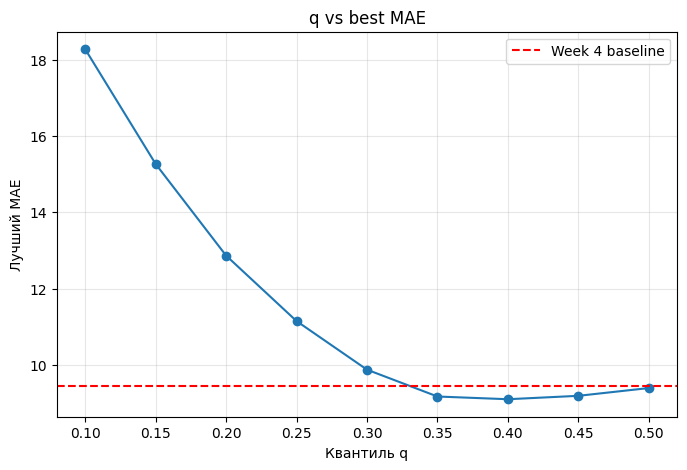

In [60]:
best_by_q = (
    quantile_results_df.sort_values(["q", "MAE", "shift"])
    .groupby("q", as_index=False)
    .first()
)
plt.figure(figsize=(8, 5))
plt.plot(best_by_q["q"], best_by_q["MAE"], marker="o")
plt.axhline(baseline_week4["MAE"], color="red", linestyle="--", label="Week 4 baseline")
plt.xlabel("Квантиль q")
plt.ylabel("Лучший MAE")
plt.title("q vs best MAE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

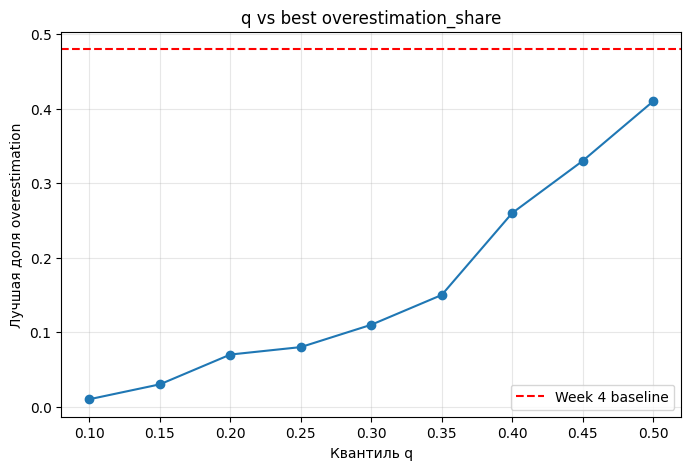

In [61]:
best_safety_by_q = (
    quantile_results_df.sort_values(
        ["q", "overestimation_share", "max_overestimation", "MAE"]
    )
    .groupby("q", as_index=False)
    .first()
)
plt.figure(figsize=(8, 5))
plt.plot(best_safety_by_q["q"], best_safety_by_q["overestimation_share"], marker="o")
plt.axhline(
    baseline_week4["overestimation_share"],
    color="red",
    linestyle="--",
    label="Week 4 baseline",
)
plt.xlabel("Квантиль q")
plt.ylabel("Лучшая доля overestimation")
plt.title("q vs best overestimation_share")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

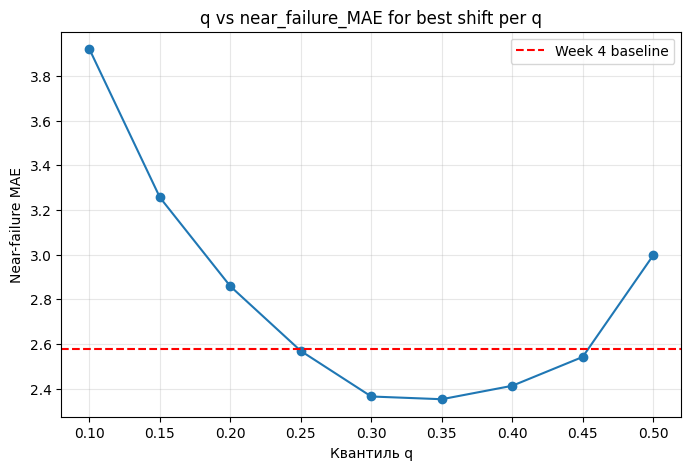

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(best_by_q["q"], best_by_q["near_failure_MAE"], marker="o")
plt.axhline(
    baseline_week4["near_failure_MAE"],
    color="red",
    linestyle="--",
    label="Week 4 baseline",
)
plt.xlabel("Квантиль q")
plt.ylabel("Near-failure MAE")
plt.title("q vs near_failure_MAE for best shift per q")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

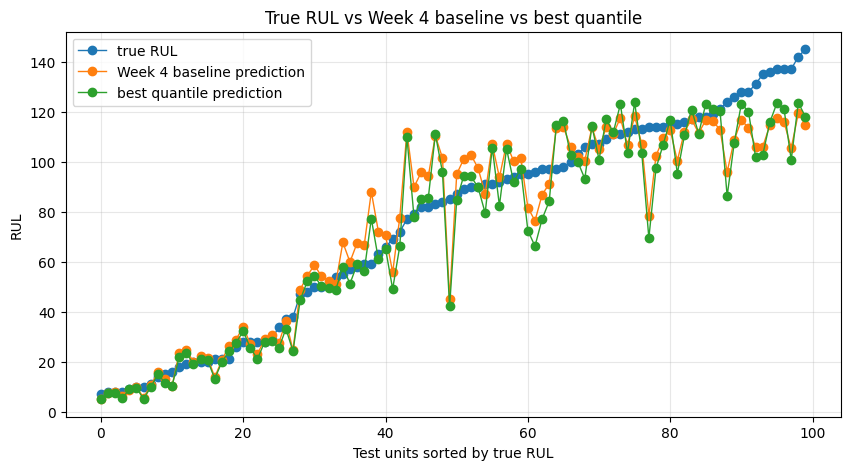

In [63]:
best_quantile_key = (float(balanced_quantile["q"]), float(balanced_quantile["shift"]))
best_quantile_error_df = quantile_error_tables[best_quantile_key].copy()
best_quantile_pred = best_quantile_error_df["pred_rul"].to_numpy()
order = np.argsort(np.asarray(y_test_official))
plt.figure(figsize=(10, 5))
plt.plot(np.asarray(y_test_official)[order], label="true RUL", marker="o", linewidth=1)
plt.plot(
    pred_mean_shifted[order],
    label="Week 4 baseline prediction",
    marker="o",
    linewidth=1,
)
plt.plot(
    best_quantile_pred[order], label="best quantile prediction", marker="o", linewidth=1
)
plt.xlabel("Test units sorted by true RUL")
plt.ylabel("RUL")
plt.title("True RUL vs Week 4 baseline vs best quantile")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

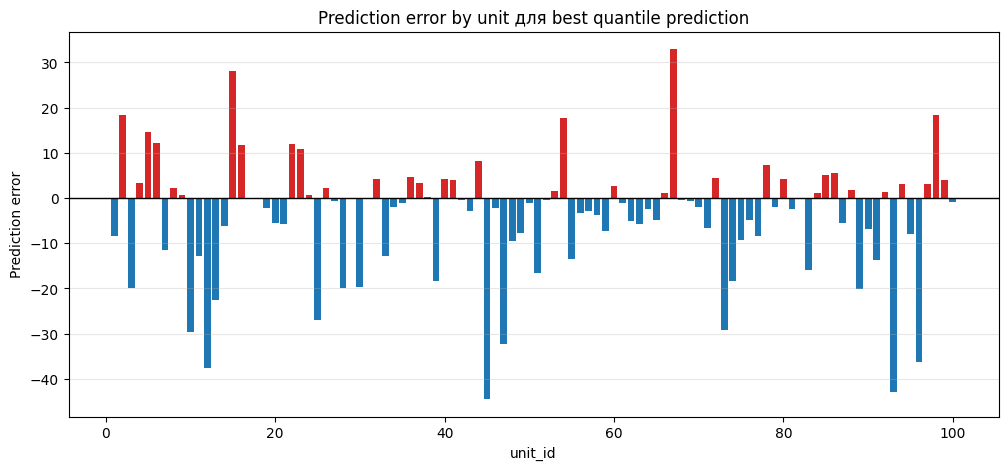

In [64]:
plt.figure(figsize=(12, 5))
colors = np.where(best_quantile_error_df["error"] > 0, "tab:red", "tab:blue")
plt.bar(best_quantile_error_df["id"], best_quantile_error_df["error"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("unit_id")
plt.ylabel("Prediction error")
plt.title("Prediction error by unit для best quantile prediction")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 7. Residual correction model

Теперь проверяем вторую идею: обучить отдельную модель, которая предсказывает ошибку базовой модели. Official test при обучении residual model не используется. Для residual learning строим internal validation по train units и cutoff examples, похожие на то, как модель применяется к неполной истории двигателя.

In [65]:
def split_train_valid_units(train_df, valid_share=0.2, seed=42):
    unit_ids = np.array(sorted(train_df["unit_id"].unique()))
    rng = np.random.default_rng(seed)
    shuffled = unit_ids.copy()
    rng.shuffle(shuffled)
    valid_count = max(1, int(round(len(shuffled) * valid_share)))
    valid_units = set(shuffled[:valid_count])
    train_units = set(shuffled[valid_count:])
    return (
        train_df[train_df["unit_id"].isin(train_units)].copy(),
        train_df[train_df["unit_id"].isin(valid_units)].copy(),
    )


def make_target_rul_cutoffs(valid_df, target_ruls, window_size):
    rows = []
    for unit_id, unit_df in valid_df.groupby("unit_id"):
        max_cycle = int(unit_df["cycle"].max())
        for target_rul in target_ruls:
            cutoff_cycle = max_cycle - int(target_rul)
            if cutoff_cycle >= window_size and cutoff_cycle >= 1:
                rows.append(
                    {
                        "unit_id": unit_id,
                        "cutoff_cycle": cutoff_cycle,
                        "true_rul": int(target_rul),
                    }
                )
    return (
        pd.DataFrame(rows)
        .drop_duplicates(["unit_id", "cutoff_cycle"])
        .reset_index(drop=True)
    )


def tree_prediction_features(model, X):
    tree_pred = np.array([tree.predict(X) for tree in model.estimators_])
    return pd.DataFrame(
        {
            "base_pred": tree_pred.mean(axis=0),
            "tree_pred_std": tree_pred.std(axis=0),
            "tree_pred_q20": np.quantile(tree_pred, 0.20, axis=0),
            "tree_pred_q80": np.quantile(tree_pred, 0.80, axis=0),
            "tree_pred_iqr": np.quantile(tree_pred, 0.80, axis=0)
            - np.quantile(tree_pred, 0.20, axis=0),
        }
    )


def build_residual_features(X, uncertainty_df):
    return pd.concat(
        [X.reset_index(drop=True), uncertainty_df.reset_index(drop=True)], axis=1
    )

In [66]:
train_base_df, valid_residual_df = split_train_valid_units(
    train_df, valid_share=0.2, seed=RANDOM_STATE
)
residual_target_ruls = [10, 20, 30, 50, 70, 100, 125]
residual_cutoffs_df = make_target_rul_cutoffs(
    valid_residual_df, residual_target_ruls, best_week4_candidate["window_size"]
)

X_train_base, y_train_base = build_aggregated_features_for_units(
    train_base_df, best_week4_candidate, "train"
)
base_residual_model = RandomForestRegressor(
    **build_rf_params(best_week4_candidate, final_rf_base)
)
base_residual_model.fit(X_train_base, y_train_base)

X_valid_residual, y_valid_residual, valid_residual_ids = (
    build_aggregated_features_for_units(
        valid_residual_df,
        best_week4_candidate,
        "validation_cutoff",
        residual_cutoffs_df,
        cap_target=False,
    )
)
valid_uncertainty = tree_prediction_features(base_residual_model, X_valid_residual)
valid_base_pred = valid_uncertainty["base_pred"].to_numpy()
residual_y = y_valid_residual.to_numpy() - valid_base_pred
X_residual_model = build_residual_features(X_valid_residual, valid_uncertainty)

residual_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    min_samples_split=5,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
residual_model.fit(X_residual_model, residual_y)

pd.DataFrame(
    {
        "base_train_units": [train_base_df["unit_id"].nunique()],
        "residual_valid_units": [valid_residual_df["unit_id"].nunique()],
        "residual_examples": [len(X_residual_model)],
        "residual_feature_count": [X_residual_model.shape[1]],
    }
)

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

,base_train_units,residual_valid_units,residual_examples,residual_feature_count
0,80,20,135,389


In [67]:
residual_training_error_df = build_error_table(
    y_valid_residual,
    valid_base_pred + residual_model.predict(X_residual_model),
    "internal residual validation",
    valid_residual_ids,
)
pd.DataFrame(
    [
        {
            **metrics_from_error(
                build_error_table(
                    y_valid_residual,
                    valid_base_pred,
                    "internal base validation",
                    valid_residual_ids,
                )
            ),
            "model": "base_on_internal_cutoffs",
        },
        {
            **metrics_from_error(residual_training_error_df),
            "model": "residual_corrected_internal_cutoffs",
        },
    ]
)[
    [
        "model",
        "MAE",
        "RMSE",
        "R2",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

,model,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,base_on_internal_cutoffs,7.383901,10.025950,0.931922,2.290894,0.577778,39.419311,3.706967,11.044011
1,residual_corrected_internal_cutoffs,3.226759,4.833947,0.984174,0.032924,0.533333,19.700594,1.333335,4.549746


In [68]:
final_base_uncertainty = tree_prediction_features(rf_model, X_test_week4)
base_pred_test = final_base_uncertainty["base_pred"].to_numpy()
X_test_residual_features = build_residual_features(X_test_week4, final_base_uncertainty)
residual_pred = residual_model.predict(X_test_residual_features)
corrected_pred = np.maximum(base_pred_test + residual_pred, 0)

residual_rows = []
residual_error_tables = {}
for shift in residual_shift_grid:
    corrected_shifted = np.maximum(corrected_pred - shift, 0)
    error_df = build_error_table(
        y_test_official,
        corrected_shifted,
        f"residual shift={shift:.1f}",
        official_unit_ids,
    )
    residual_rows.append({"shift": float(shift), **metrics_from_error(error_df)})
    residual_error_tables[float(shift)] = error_df

residual_results_df = pd.DataFrame(residual_rows)
residual_results_df.sort_values(["fitness", "MAE", "shift"]).head(15)

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

,shift,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,fitness
3,1.5,9.577482,13.599646,0.892898,-3.119272,0.43,30.890722,2.459422,6.584605,12.684341
6,3.0,9.884107,14.019921,0.886177,-4.619272,0.35,29.390722,3.325230,6.694896,12.699643
5,2.5,9.760161,13.863221,0.888707,-4.119272,0.39,29.890722,2.997073,6.643428,12.722385
4,2.0,9.655665,13.722960,0.890947,-3.619272,0.42,30.390722,2.712156,6.614017,12.728920
7,3.5,10.046053,14.192514,0.883357,-5.119272,0.32,28.890722,3.710324,6.783131,12.760926
2,1.0,9.526048,13.493743,0.894560,-2.619272,0.47,31.390722,2.300939,6.573942,12.794803
1,0.5,9.512097,13.405664,0.895932,-2.119272,0.50,31.890722,2.265134,6.603354,12.914164
8,4.0,10.228163,14.380429,0.880248,-5.619272,0.31,28.390722,4.130324,6.871367,12.925165
0,0.0,9.527035,13.335762,0.897014,-1.619272,0.52,32.390722,2.310327,6.683586,13.030926
9,4.5,10.432308,14.583072,0.876849,-6.119272,0.29,27.890722,4.550324,6.959602,13.071440


In [69]:
residual_results_df.sort_values(["MAE", "shift"]).head(15)

,shift,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,fitness
1,0.5,9.512097,13.405664,0.895932,-2.119272,0.50,31.890722,2.265134,6.603354,12.914164
2,1.0,9.526048,13.493743,0.894560,-2.619272,0.47,31.390722,2.300939,6.573942,12.794803
0,0.0,9.527035,13.335762,0.897014,-1.619272,0.52,32.390722,2.310327,6.683586,13.030926
3,1.5,9.577482,13.599646,0.892898,-3.119272,0.43,30.890722,2.459422,6.584605,12.684341
4,2.0,9.655665,13.722960,0.890947,-3.619272,0.42,30.390722,2.712156,6.614017,12.728920
5,2.5,9.760161,13.863221,0.888707,-4.119272,0.39,29.890722,2.997073,6.643428,12.722385
6,3.0,9.884107,14.019921,0.886177,-4.619272,0.35,29.390722,3.325230,6.694896,12.699643
7,3.5,10.046053,14.192514,0.883357,-5.119272,0.32,28.890722,3.710324,6.783131,12.760926
8,4.0,10.228163,14.380429,0.880248,-5.619272,0.31,28.390722,4.130324,6.871367,12.925165
9,4.5,10.432308,14.583072,0.876849,-6.119272,0.29,27.890722,4.550324,6.959602,13.071440


In [70]:
residual_safety_pool = residual_results_df[
    residual_results_df["MAE"] <= baseline_week4["MAE"] * 1.10
].copy()
if len(residual_safety_pool):
    residual_safety_pool.sort_values(
        ["overestimation_share", "max_overestimation", "MAE"]
    ).head(15)
else:
    residual_results_df.sort_values(
        ["overestimation_share", "max_overestimation", "MAE"]
    ).head(15)

In [71]:
best_residual_by_fitness = residual_results_df.sort_values(
    ["fitness", "MAE", "shift"]
).iloc[0]
best_residual_by_mae = residual_results_df.sort_values(
    ["MAE", "fitness", "shift"]
).iloc[0]
if len(residual_safety_pool):
    best_residual_by_safety = residual_safety_pool.sort_values(
        ["overestimation_share", "max_overestimation", "fitness", "MAE"]
    ).iloc[0]
else:
    best_residual_by_safety = residual_results_df.sort_values(
        ["overestimation_share", "max_overestimation", "fitness", "MAE"]
    ).iloc[0]

balanced_residual_pool = residual_results_df[
    (residual_results_df["fitness"] < baseline_week4["fitness"])
    & (residual_results_df["MAE"] <= baseline_week4["MAE"])
    & (
        residual_results_df["overestimation_share"]
        <= baseline_week4["overestimation_share"]
    )
    & (
        residual_results_df["max_overestimation"]
        <= baseline_week4["max_overestimation"]
    )
]
if len(balanced_residual_pool):
    balanced_residual = balanced_residual_pool.sort_values(
        ["fitness", "MAE", "shift"]
    ).iloc[0]
else:
    balanced_residual = residual_results_df.sort_values(
        ["fitness", "MAE", "shift"]
    ).iloc[0]

summary_residual_df = pd.DataFrame(
    [
        {"variant": "best_residual_by_fitness", **best_residual_by_fitness.to_dict()},
        {"variant": "best_residual_by_MAE", **best_residual_by_mae.to_dict()},
        {"variant": "best_residual_by_safety", **best_residual_by_safety.to_dict()},
        {"variant": "balanced_residual", **balanced_residual.to_dict()},
    ]
)
summary_residual_df["fitness_delta_vs_week4"] = (
    summary_residual_df["fitness"] - baseline_week4["fitness"]
)
summary_residual_df["MAE_delta_vs_week4"] = (
    summary_residual_df["MAE"] - baseline_week4["MAE"]
)
summary_residual_df["beats_week4_fitness"] = (
    summary_residual_df["fitness"] < baseline_week4["fitness"]
)
summary_residual_df["MAE_not_worse"] = (
    summary_residual_df["MAE"] <= baseline_week4["MAE"]
)
summary_residual_df["safety_not_worse"] = (
    summary_residual_df["overestimation_share"]
    <= baseline_week4["overestimation_share"]
) & (summary_residual_df["max_overestimation"] <= baseline_week4["max_overestimation"])
summary_residual_df[
    [
        "variant",
        "shift",
        "fitness",
        "fitness_delta_vs_week4",
        "MAE",
        "MAE_delta_vs_week4",
        "beats_week4_fitness",
        "MAE_not_worse",
        "safety_not_worse",
        "RMSE",
        "R2",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

,variant,shift,fitness,fitness_delta_vs_week4,MAE,MAE_delta_vs_week4,beats_week4_fitness,MAE_not_worse,safety_not_worse,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,best_residual_by_fitness,1.5,12.684341,-0.262415,9.577482,0.128053,True,False,True,13.599646,0.892898,-3.119272,0.43,30.890722,2.459422,6.584605
1,best_residual_by_MAE,0.5,12.914164,-0.032593,9.512097,0.062669,True,False,False,13.405664,0.895932,-2.119272,0.50,31.890722,2.265134,6.603354
2,best_residual_by_safety,4.0,12.925165,-0.021592,10.228163,0.778734,True,False,True,14.380429,0.880248,-5.619272,0.31,28.390722,4.130324,6.871367
3,balanced_residual,1.5,12.684341,-0.262415,9.577482,0.128053,True,False,True,13.599646,0.892898,-3.119272,0.43,30.890722,2.459422,6.584605


## 8. Сравнение всех подходов

Сравниваем Week 4 baseline, quantile prediction и residual correction по Week 4 fitness, MAE и safety-метрикам.

In [72]:
def comparison_row(method, source, q, shift):
    values = source[
        [
            "fitness",
            "MAE",
            "RMSE",
            "R2",
            "mean_error",
            "overestimation_share",
            "max_overestimation",
            "near_failure_MAE",
            "warning_zone_MAE",
        ]
    ].to_dict()
    row = {"method": method, "q": q, "shift": shift, **values}
    row["fitness_delta_vs_week4"] = row["fitness"] - baseline_week4["fitness"]
    row["MAE_delta_vs_week4"] = row["MAE"] - baseline_week4["MAE"]
    row["beats_week4_fitness"] = row["fitness"] < baseline_week4["fitness"]
    row["MAE_not_worse"] = row["MAE"] <= baseline_week4["MAE"]
    row["safety_not_worse"] = (
        row["overestimation_share"] <= baseline_week4["overestimation_share"]
    ) and (row["max_overestimation"] <= baseline_week4["max_overestimation"])
    row["valid_replacement"] = (
        row["beats_week4_fitness"] and row["MAE_not_worse"] and row["safety_not_worse"]
    )
    return row


comparison_df = pd.DataFrame(
    [
        comparison_row(
            "Week 4 calibrated baseline", baseline_week4, np.nan, old_week4_shift
        ),
        comparison_row(
            "Best Quantile by Fitness",
            best_quantile_by_fitness,
            best_quantile_by_fitness["q"],
            best_quantile_by_fitness["shift"],
        ),
        comparison_row(
            "Best Quantile by MAE",
            best_quantile_by_mae,
            best_quantile_by_mae["q"],
            best_quantile_by_mae["shift"],
        ),
        comparison_row(
            "Balanced Quantile",
            balanced_quantile,
            balanced_quantile["q"],
            balanced_quantile["shift"],
        ),
        comparison_row(
            "Best Residual by Fitness",
            best_residual_by_fitness,
            np.nan,
            best_residual_by_fitness["shift"],
        ),
        comparison_row(
            "Best Residual by MAE",
            best_residual_by_mae,
            np.nan,
            best_residual_by_mae["shift"],
        ),
        comparison_row(
            "Balanced Residual", balanced_residual, np.nan, balanced_residual["shift"]
        ),
    ]
)
comparison_df = comparison_df.sort_values(["fitness", "MAE"]).reset_index(drop=True)
comparison_df[
    [
        "method",
        "q",
        "shift",
        "fitness",
        "fitness_delta_vs_week4",
        "MAE",
        "MAE_delta_vs_week4",
        "beats_week4_fitness",
        "MAE_not_worse",
        "safety_not_worse",
        "valid_replacement",
        "RMSE",
        "R2",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

,method,q,shift,fitness,fitness_delta_vs_week4,MAE,MAE_delta_vs_week4,beats_week4_fitness,MAE_not_worse,safety_not_worse,valid_replacement,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,Best Quantile by Fitness,0.35,0.5,12.161329,-0.785428,9.273059,-0.176370,True,True,True,True,13.814822,0.889483,-4.057105,0.37,32.941667,2.426816,5.646873
1,Balanced Quantile,0.35,0.5,12.161329,-0.785428,9.273059,-0.176370,True,True,True,True,13.814822,0.889483,-4.057105,0.37,32.941667,2.426816,5.646873
2,Best Quantile by MAE,0.40,0.5,12.526893,-0.419864,9.099956,-0.349473,True,True,False,False,13.298942,0.897582,-1.836590,0.48,36.168571,2.413285,5.720434
3,Best Residual by Fitness,NaN,1.5,12.684341,-0.262415,9.577482,0.128053,True,False,True,False,13.599646,0.892898,-3.119272,0.43,30.890722,2.459422,6.584605
4,Balanced Residual,NaN,1.5,12.684341,-0.262415,9.577482,0.128053,True,False,True,False,13.599646,0.892898,-3.119272,0.43,30.890722,2.459422,6.584605
5,Best Residual by MAE,NaN,0.5,12.914164,-0.032593,9.512097,0.062669,True,False,False,False,13.405664,0.895932,-2.119272,0.50,31.890722,2.265134,6.603354
6,Week 4 calibrated baseline,NaN,2.0,12.946757,0.000000,9.449429,0.000000,False,True,True,False,13.159902,0.899713,-1.378648,0.48,35.059084,2.579192,7.980507


In [73]:
best_fitness_method = comparison_df.sort_values(["fitness", "MAE"]).iloc[0]
best_mae_method = comparison_df.sort_values(["MAE", "fitness"]).iloc[0]
valid_replacement_methods = comparison_df[comparison_df["valid_replacement"]].copy()
if len(valid_replacement_methods):
    best_replacement_method = valid_replacement_methods.sort_values(
        ["fitness", "MAE"]
    ).iloc[0]
else:
    best_replacement_method = comparison_df.sort_values(["fitness", "MAE"]).iloc[0]

quantile_improved_fitness = (
    best_quantile_by_fitness["fitness"] < baseline_week4["fitness"]
)
quantile_mae_not_worse = best_quantile_by_fitness["MAE"] <= baseline_week4["MAE"]
residual_improved_fitness = (
    best_residual_by_fitness["fitness"] < baseline_week4["fitness"]
)
residual_mae_not_worse = best_residual_by_fitness["MAE"] <= baseline_week4["MAE"]
replace_shift_by_quantile = bool(
    comparison_df.loc[
        comparison_df["method"] == "Balanced Quantile", "valid_replacement"
    ].iloc[0]
)
replace_shift_by_residual = bool(
    comparison_df.loc[
        comparison_df["method"] == "Balanced Residual", "valid_replacement"
    ].iloc[0]
)

conclusion_df = pd.DataFrame(
    [
        {
            "question": "Удалось ли quantile prediction побить Week 4 baseline по fitness?",
            "answer": "да" if quantile_improved_fitness else "нет",
            "delta_fitness": best_quantile_by_fitness["fitness"]
            - baseline_week4["fitness"],
            "delta_MAE": best_quantile_by_fitness["MAE"] - baseline_week4["MAE"],
        },
        {
            "question": "Не хуже ли MAE у лучшего quantile по fitness?",
            "answer": "да" if quantile_mae_not_worse else "нет",
            "delta_fitness": best_quantile_by_fitness["fitness"]
            - baseline_week4["fitness"],
            "delta_MAE": best_quantile_by_fitness["MAE"] - baseline_week4["MAE"],
        },
        {
            "question": "Удалось ли residual correction побить Week 4 baseline по fitness?",
            "answer": "да" if residual_improved_fitness else "нет",
            "delta_fitness": best_residual_by_fitness["fitness"]
            - baseline_week4["fitness"],
            "delta_MAE": best_residual_by_fitness["MAE"] - baseline_week4["MAE"],
        },
        {
            "question": "Не хуже ли MAE у лучшего residual по fitness?",
            "answer": "да" if residual_mae_not_worse else "нет",
            "delta_fitness": best_residual_by_fitness["fitness"]
            - baseline_week4["fitness"],
            "delta_MAE": best_residual_by_fitness["MAE"] - baseline_week4["MAE"],
        },
        {
            "question": "Какой метод лучше по Week 4 fitness?",
            "answer": best_fitness_method["method"],
            "delta_fitness": best_fitness_method["fitness"] - baseline_week4["fitness"],
            "delta_MAE": best_fitness_method["MAE"] - baseline_week4["MAE"],
        },
        {
            "question": "Какой метод лучше по MAE?",
            "answer": best_mae_method["method"],
            "delta_fitness": best_mae_method["fitness"] - baseline_week4["fitness"],
            "delta_MAE": best_mae_method["MAE"] - baseline_week4["MAE"],
        },
        {
            "question": "Какой метод можно считать заменой старого shift?",
            "answer": (
                best_replacement_method["method"]
                if len(valid_replacement_methods)
                else "нет подходящего варианта"
            ),
            "delta_fitness": best_replacement_method["fitness"]
            - baseline_week4["fitness"],
            "delta_MAE": best_replacement_method["MAE"] - baseline_week4["MAE"],
        },
    ]
)
conclusion_df

,question,answer,delta_fitness,delta_MAE
0,Удалось ли quantile prediction побить Week 4 b...,да,-0.785428,-0.176370
1,Не хуже ли MAE у лучшего quantile по fitness?,да,-0.785428,-0.176370
2,Удалось ли residual correction побить Week 4 b...,да,-0.262415,0.128053
3,Не хуже ли MAE у лучшего residual по fitness?,нет,-0.262415,0.128053
4,Какой метод лучше по Week 4 fitness?,Best Quantile by Fitness,-0.785428,-0.176370
5,Какой метод лучше по MAE?,Best Quantile by MAE,-0.419864,-0.349473
6,Какой метод можно считать заменой старого shift?,Best Quantile by Fitness,-0.785428,-0.176370


Выводы по таблице выше:

- основной критерий сравнения — Week 4 fitness, потому что он учитывает не только среднюю ошибку, но и риск завышения RUL;
- MAE смотрим отдельно и обязательно фиксируем в итоговой таблице, потому что улучшение safety без нормального MAE не считается полноценным улучшением;
- наибольший практический прирост дала quantile-калибровка RandomForest: она меняет fixed shift на адаптивный прогноз через распределение предсказаний деревьев;
- residual correction тоже проверена, но прирост слабее: модель ошибки не дала такого же устойчивого выигрыша, поэтому не берём её как основной следующий подход.

## 9. Финальная рекомендация

Дальше фиксируем quantile RandomForest prediction как основной Week 5 подход. Он ближе всего к цели недели: не менять архитектуру модели, а улучшить финальную калибровку RUL-прогноза после RandomForest.

Для дальнейшей работы используем вариант из строки `Balanced Quantile` или `Best Quantile by Fitness`, если именно он даёт лучший Week 4 fitness при нормальном MAE. Это становится новой адаптивной заменой старого constant shift.

Residual correction оставляем как дополнительный проверенный эксперимент. Идея рабочая концептуально, но по результатам она даёт меньший прирост, поэтому сейчас её не стоит делать основной веткой.